<a href="https://colab.research.google.com/github/OpenTruce/36-Hours-Python-Tutorial/blob/main/LoRa_Trilateration_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       SIMULATION RESULTS (PROJECT-I)
Gateway 1: Pos=(0.0, 0.0) | True Dist=15.62m | RSSI=-75.40dBm | Est Dist=13.37m
Gateway 2: Pos=(25.0, 0.0) | True Dist=19.21m | RSSI=-83.15dBm | Est Dist=25.88m
Gateway 3: Pos=(12.5, 22.0) | True Dist=10.31m | RSSI=-75.91dBm | Est Dist=13.96m
---------------------------------------------
True Target Position      : (10.00, 12.00)
Estimated Target Position : (2.43, 12.79)
Localization Error (RMSE) : 7.61 meters


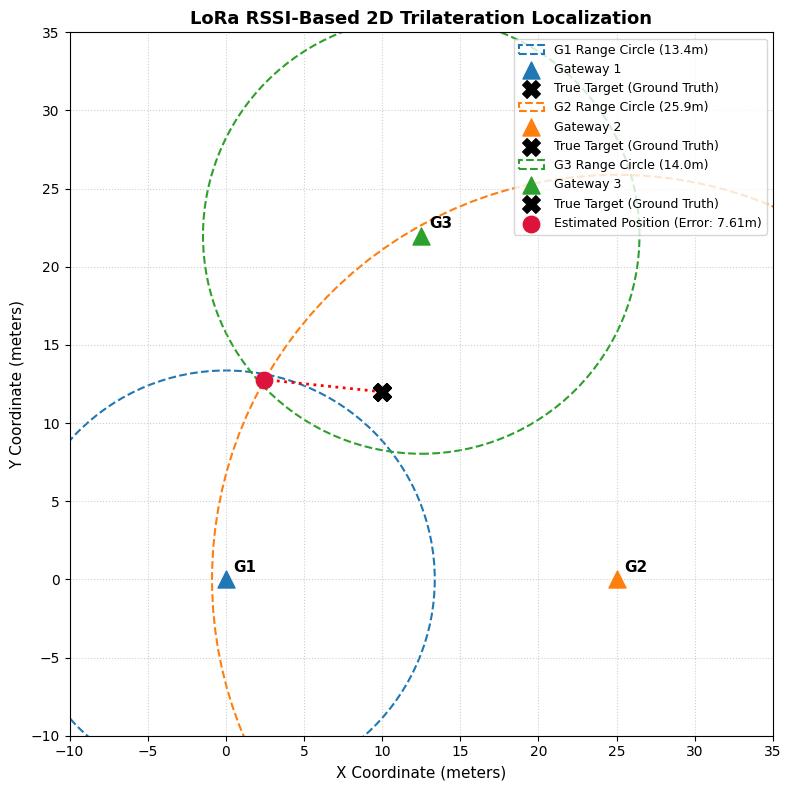

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
A=-45.0
n=2.7
noise_std=2.0
gateways = np.array([
    [0.0, 0.0],
    [25.0, 0.0],
    [12.5, 22.0]
])
true_target=np.array([10.0, 12.0])
true_distances=np.linalg.norm(gateways-true_target, axis=1)
simulated_rssi=A-(10*n*np.log10(true_distances))+np.random.normal(0, noise_std, size=3)
estimated_distances=10 ** ((A - simulated_rssi) / (10 * n))
def objective_function(pos):
    calc_dists=np.linalg.norm(gateways - pos, axis=1)
    return np.sum((calc_dists**2 - estimated_distances**2)**2)
initial_guess=np.mean(gateways, axis=0)
solver_result=minimize(objective_function, initial_guess, method='BFGS')
est_target=solver_result.x
localization_error=np.linalg.norm(true_target - est_target)
print("="*45)
print("       SIMULATION RESULTS (PROJECT-I)")
print("="*45)
for i in range(3):
    print(f"Gateway {i+1}: Pos=({gateways[i][0]:.1f}, {gateways[i][1]:.1f}) | True Dist={true_distances[i]:.2f}m | RSSI={simulated_rssi[i]:.2f}dBm | Est Dist={estimated_distances[i]:.2f}m")
print("-"*45)
print(f"True Target Position      : ({true_target[0]:.2f}, {true_target[1]:.2f})")
print(f"Estimated Target Position : ({est_target[0]:.2f}, {est_target[1]:.2f})")
print(f"Localization Error (RMSE) : {localization_error:.2f} meters")
print("="*45)
fig, ax=plt.subplots(figsize=(8, 8))
colors=['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    circle=plt.Circle(gateways[i], estimated_distances[i], color=colors[i], fill=False, linestyle='--', linewidth=1.5, label=f'G{i+1} Range Circle ({estimated_distances[i]:.1f}m)')
    ax.add_patch(circle)
    ax.scatter(gateways[i][0], gateways[i][1], color=colors[i], marker='^', s=150, zorder=5, label=f'Gateway {i+1}')
    ax.text(gateways[i][0]+0.5, gateways[i][1]+0.5, f"G{i+1}", fontsize=11, fontweight='bold')
    ax.scatter(true_target[0], true_target[1], color='black', marker='X', s=160, zorder=6, label='True Target (Ground Truth)')
ax.scatter(est_target[0], est_target[1], color='crimson', marker='o', s=140, zorder=6, label=f'Estimated Position (Error: {localization_error:.2f}m)')
ax.plot([true_target[0], est_target[0]], [true_target[1], est_target[1]], 'r:', linewidth=2)
ax.set_title("LoRa RSSI-Based 2D Trilateration Localization", fontsize=13, fontweight='bold')
ax.set_xlabel("X Coordinate (meters)", fontsize=11)
ax.set_ylabel("Y Coordinate (meters)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')
ax.set_xlim(-10, 35)
ax.set_ylim(-10, 35)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("trilateration_simulation.png", dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
A=-45.0
n=2.7
noise_std=2.0
gateways = np.array([
    [0.0, 0.0],
    [25.0, 0.0],
    [12.5, 22.0]
])

In [ ]:
true_target=np.array([10.0, 12.0])
true_distances=np.linalg.norm(gateways-true_target, axis=1)
simulated_rssi=A-(10*n*np.log10(true_distances))+np.random.normal(0, noise_std, size=3)
estimated_distances=10 ** ((A - simulated_rssi) / (10 * n))

SIMULATION RESULTS (PROJECT-I)
Gateway 1: Pos=(0.0, 0.0) | True Dist=15.62m | RSSI=-79.71dBm | Est Dist=19.29m
Gateway 2: Pos=(25.0, 0.0) | True Dist=19.21m | RSSI=-80.83dBm | Est Dist=21.24m
Gateway 3: Pos=(12.5, 22.0) | True Dist=10.31m | RSSI=-69.64dBm | Est Dist=8.18m
---------------------------------------------
True Target Position      : (10.00, 12.00)
Estimated Target Position : (10.83, 15.74)
Localization Error (RMSE) : 3.83 meters


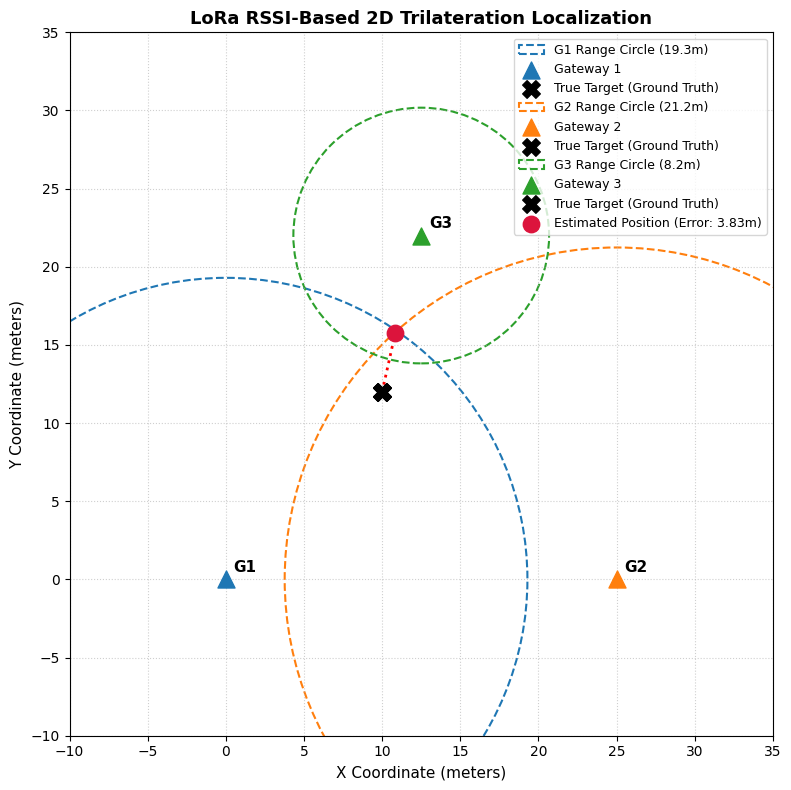

In [ ]:
def objective_function(pos):
    calc_dists=np.linalg.norm(gateways-pos, axis=1)
    return np.sum((calc_dists**2-estimated_distances**2)**2)
initial_guess=np.mean(gateways, axis=0)
solver_result=minimize(objective_function, initial_guess, method='BFGS')
est_target=solver_result.x
localization_error=np.linalg.norm(true_target-est_target)
print("="*45)
print("SIMULATION RESULTS (PROJECT-I)")
print("="*45)
for i in range(3):
    print(f"Gateway {i+1}: Pos=({gateways[i][0]:.1f}, {gateways[i][1]:.1f}) | True Dist={true_distances[i]:.2f}m | RSSI={simulated_rssi[i]:.2f}dBm | Est Dist={estimated_distances[i]:.2f}m")
print("-"*45)
print(f"True Target Position      : ({true_target[0]:.2f}, {true_target[1]:.2f})")
print(f"Estimated Target Position : ({est_target[0]:.2f}, {est_target[1]:.2f})")
print(f"Localization Error (RMSE) : {localization_error:.2f} meters")
print("="*45)
fig, ax=plt.subplots(figsize=(8, 8))
colors=['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    circle=plt.Circle(gateways[i], estimated_distances[i], color=colors[i], fill=False, linestyle='--', linewidth=1.5, label=f'G{i+1} Range Circle ({estimated_distances[i]:.1f}m)')
    ax.add_patch(circle)
    ax.scatter(gateways[i][0], gateways[i][1], color=colors[i], marker='^', s=150, zorder=5, label=f'Gateway {i+1}')
    ax.text(gateways[i][0]+0.5, gateways[i][1]+0.5, f"G{i+1}", fontsize=11, fontweight='bold')
    ax.scatter(true_target[0], true_target[1], color='black', marker='X', s=160, zorder=6, label='True Target (Ground Truth)')
ax.scatter(est_target[0], est_target[1], color='crimson', marker='o', s=140, zorder=6, label=f'Estimated Position (Error: {localization_error:.2f}m)')
ax.plot([true_target[0], est_target[0]], [true_target[1], est_target[1]], 'r:', linewidth=2)
ax.set_title("LoRa RSSI-Based 2D Trilateration Localization", fontsize=13, fontweight='bold')
ax.set_xlabel("X Coordinate (meters)", fontsize=11)
ax.set_ylabel("Y Coordinate (meters)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')
ax.set_xlim(-10, 35)
ax.set_ylim(-10, 35)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("trilateration_simulation.png", dpi=300)
plt.show()
